# Teknik Pengelompokan (Clustering Techniques)

Catatan ini menguraikan konsep dan implementasi algoritma Pengelompokan (*Clustering*), yang merupakan bagian dari paradigma *Unsupervised Learning* (Pembelajaran Tanpa Pengawasan). Berbeda dengan klasifikasi, pengelompokan bertujuan untuk mempartisi himpunan data ke dalam kelompok-kelompok homogen tanpa adanya label target aktual (*ground truth*).

Modul ini mendalami tiga algoritma pengelompokan paling fundamental di industri: **K-Means**, **Agglomerative Clustering**, dan **DBSCAN**. Selain itu, dibahas pula tantangan dalam mengevaluasi performa model *clustering* menggunakan metrik analitik seperti *Adjusted Rand Index* (ARI) dan *Silhouette Score*.

#### **Tujuan Pembelajaran**
* Memahami prinsip kerja partisi berbasis pusat massa (*centroid*) melalui algoritma K-Means.
* Menyadari kelemahan K-Means pada data dengan bentuk geometris yang kompleks (non-sferis).
* Mengimplementasikan pengelompokan hierarkis (*Agglomerative*) dan menginterpretasikan struktur data menggunakan Dendrogram.
* Menerapkan DBSCAN untuk mendeteksi klaster berbasis kepadatan ruang (*density-based*) serta mengidentifikasi anomali (*outliers*).
* Mengevaluasi kualitas klaster secara kuantitatif menggunakan metrik evaluasi internal maupun eksternal.

In [43]:
# Memuat pustaka komputasi numerik dan visualisasi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Memuat pembuat dataset sintetis
from sklearn.datasets import make_blobs, make_moons

# Memuat modul algoritma pengelompokan (Clustering)
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# Memuat pustaka untuk komputasi hierarki dan dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage

# Memuat metrik evaluasi klaster
from sklearn.metrics import adjusted_rand_score, silhouette_score

# Memuat modul penskalaan data
from sklearn.preprocessing import StandardScaler

# Konfigurasi visualisasi
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

print("Pustaka untuk Teknik Pengelompokan berhasil dimuat.")

Pustaka untuk Teknik Pengelompokan berhasil dimuat.


## 1. K-Means Clustering

K-Means adalah algoritma pengelompokan yang paling populer karena kesederhanaan dan efisiensi komputasinya. Algoritma ini beroperasi dengan mempartisi data ke dalam himpunan $K$ klaster, di mana setiap titik data dialokasikan ke klaster yang pusat massanya (*centroid*) paling dekat (diukur menggunakan jarak Euclidean).

**Kelemahan K-Means:**
Algoritma ini berasumsi bahwa klaster berbentuk sferis (bulat) dan memiliki variansi spasial yang seragam. K-Means akan gagal secara absolut ketika dihadapkan pada himpunan data yang melengkung, memanjang, atau memiliki kepadatan yang sangat bervariasi.

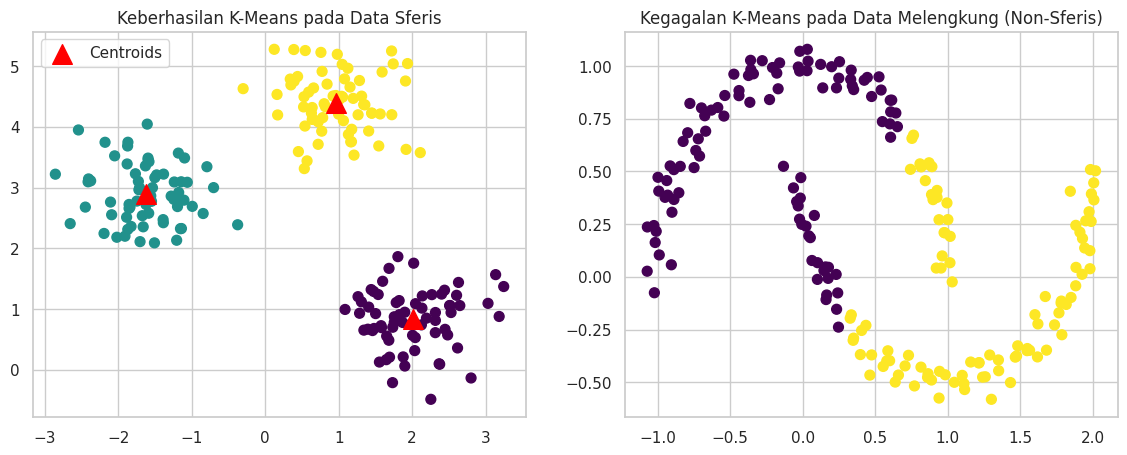

In [44]:
# 1. K-Means pada Dataset Ideal (Blobs)
X_blobs, y_blobs = make_blobs(n_samples=200, centers=3, cluster_std=0.5, random_state=0)

kmeans_ideal = KMeans(n_clusters=3, random_state=0)
label_ideal = kmeans_ideal.fit_predict(X_blobs)

# 2. K-Means pada Dataset Non-Sferis (Moons)
X_moons, y_moons = make_moons(n_samples=200, noise=0.05, random_state=0)

kmeans_moons = KMeans(n_clusters=2, random_state=0)
label_moons = kmeans_moons.fit_predict(X_moons)

# Visualisasi Komparatif
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Dataset Ideal
axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c=label_ideal, cmap='viridis', s=50)
axes[0].scatter(kmeans_ideal.cluster_centers_[:, 0], kmeans_ideal.cluster_centers_[:, 1],
                marker='^', s=200, c='red', label='Centroids')
axes[0].set_title("Keberhasilan K-Means pada Data Sferis")
axes[0].legend()

# Plot Dataset Kompleks (Moons)
axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c=label_moons, cmap='viridis', s=50)
axes[1].set_title("Kegagalan K-Means pada Data Melengkung (Non-Sferis)")

plt.show()

## 2. Pengelompokan Hierarkis (*Agglomerative Clustering*)

*Agglomerative Clustering* beroperasi dengan pendekatan *bottom-up* (dari bawah ke atas). Awalnya, setiap titik data dianggap sebagai satu klaster independen. Algoritma kemudian secara bertahap menggabungkan dua klaster yang jaraknya paling berdekatan hingga akhirnya seluruh titik data tergabung ke dalam satu klaster raksasa.

Keunggulan utama pendekatan ini adalah kita tidak perlu mendefinisikan jumlah $K$ secara kaku di awal. Proses penggabungan ini dapat divisualisasikan secara holistik menggunakan **Dendrogram**, yang memungkinkan praktisi menentukan jumlah klaster pemotongan secara visual.

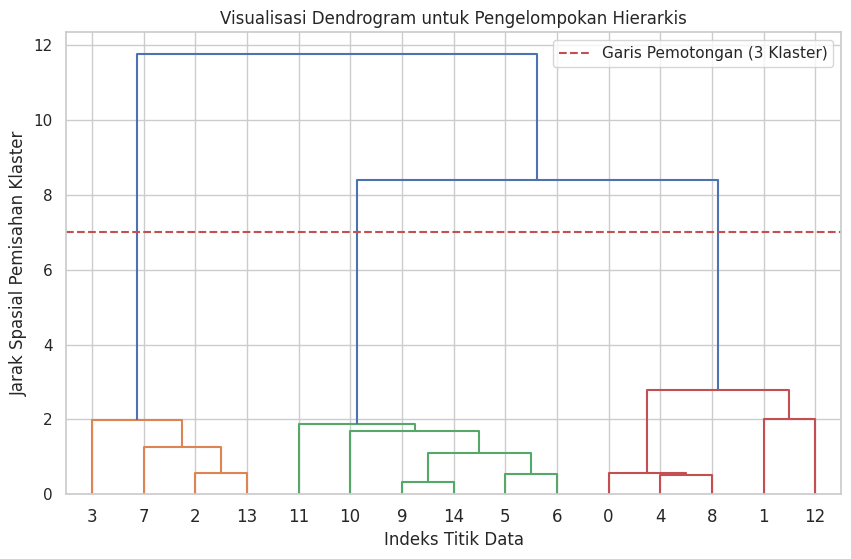

In [45]:
# Pembuatan dataset spasial terbatas
X_hierarki, _ = make_blobs(random_state=0, n_samples=15)

# Melakukan komputasi matriks tautan hierarki (Linkage Matrix)
# Menggunakan metode 'ward' yang meminimalkan variansi dalam klaster saat penggabungan
matriks_tautan = linkage(X_hierarki, method='ward')

plt.figure(figsize=(10, 6))
# Render Dendrogram
dendrogram(matriks_tautan)

plt.title("Visualisasi Dendrogram untuk Pengelompokan Hierarkis")
plt.xlabel("Indeks Titik Data")
plt.ylabel("Jarak Spasial Pemisahan Klaster")
plt.axhline(y=7, color='r', linestyle='--', label='Garis Pemotongan (3 Klaster)')
plt.legend()
plt.show()

# Implementasi Scikit-Learn untuk Agglomerative Clustering dengan 3 Klaster
agg_model = AgglomerativeClustering(n_clusters=3)
label_agg = agg_model.fit_predict(X_hierarki)

## 3. Pengelompokan Berbasis Kepadatan (*DBSCAN*)

*Density-Based Spatial Clustering of Applications with Noise* (DBSCAN) menyelesaikan masalah struktural yang gagal ditangani oleh K-Means. Alih-alih mengukur jarak ke pusat massa, DBSCAN mendefinisikan klaster sebagai area di mana titik data tersusun dengan kepadatan tinggi, yang dipisahkan oleh area dengan kepadatan rendah.

DBSCAN memiliki dua properti unggulan:
1. **Tidak memerlukan parameter jumlah klaster di awal.**
2. **Mampu mendeteksi *Noise* (Anomali).** Titik data yang terisolasi di area kepadatan rendah tidak akan dipaksakan masuk ke dalam klaster manapun (diberi label `-1`).

Dua parameter utamanya adalah `eps` (radius pencarian tetangga) dan `min_samples` (syarat minimum jumlah titik dalam radius untuk membentuk klaster inti).

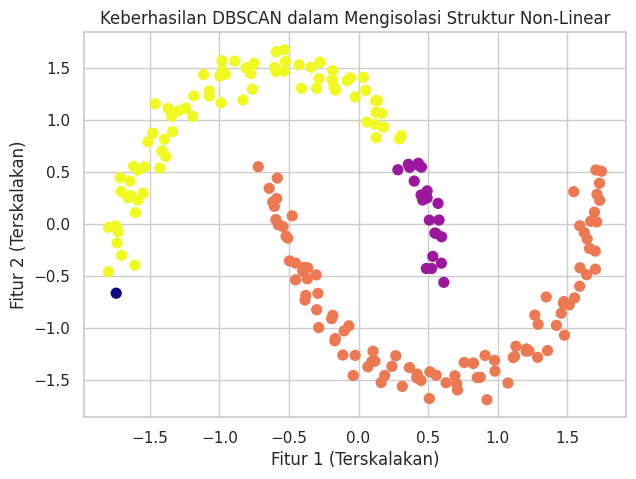

In [46]:
# Prapemrosesan: Algoritma berbasis jarak wajib dilakukan standardisasi skala
scaler = StandardScaler()
X_moons_scaled = scaler.fit_transform(X_moons)

# Mengaplikasikan DBSCAN pada himpunan data melengkung (Moons)
# Radius (eps) dan syarat sampel diatur sesuai dengan kerapatan data
dbscan = DBSCAN(eps=0.25, min_samples=5)
label_dbscan = dbscan.fit_predict(X_moons_scaled)

plt.figure(figsize=(7, 5))
# Titik dengan label -1 adalah Noise/Outliers
plt.scatter(X_moons_scaled[:, 0], X_moons_scaled[:, 1], c=label_dbscan, cmap='plasma', s=50)
plt.title("Keberhasilan DBSCAN dalam Mengisolasi Struktur Non-Linear")
plt.xlabel("Fitur 1 (Terskalakan)")
plt.ylabel("Fitur 2 (Terskalakan)")
plt.show()

## 4. Evaluasi Performa Pengelompokan

Berbeda dengan sistem klasifikasi yang dapat menggunakan *Accuracy* atau *Recall*, algoritma *Unsupervised* jauh lebih sulit dievaluasi secara matematis. Evaluasi dibagi menjadi dua pendekatan:

1. **Dengan Kebenaran Aktual (*Ground Truth*): Adjusted Rand Index (ARI)**
   Menghitung tingkat kecocokan antara klaster hasil prediksi dengan label asli kelas. Skor berkisar dari -1 hingga 1. Skor 1 merepresentasikan pemisahan yang identik sempurna, sedangkan 0 merepresentasikan pengelompokan yang sepenuhnya acak.
   
2. **Tanpa Kebenaran Aktual: Silhouette Score**
   Menghitung seberapa padat jarak intra-klaster (jarak antar-anggota dalam satu klaster yang sama) dibandingkan dengan jarak ekstra-klaster (jarak dengan klaster terdekat lainnya). Skor berkisar dari -1 hingga 1. Skor 1 mengindikasikan bahwa klaster terpisah dengan kepadatan yang sangat terdefinisi.

In [47]:
# 1. Evaluasi menggunakan Adjusted Rand Index (Menggunakan label asli y_moons)
ari_kmeans = adjusted_rand_score(y_moons, label_moons)
ari_dbscan = adjusted_rand_score(y_moons, label_dbscan)

# 2. Evaluasi menggunakan Silhouette Score (Tidak menggunakan label asli)
# Catatan: Silhouette score sensitif pada struktur klaster geometris
sil_kmeans = silhouette_score(X_moons_scaled, label_moons)
sil_dbscan = silhouette_score(X_moons_scaled, label_dbscan)

# Menampilkan Laporan Komparasi
df_evaluasi = pd.DataFrame({
    "Metrik Evaluasi": ["Adjusted Rand Index (ARI)", "Silhouette Score"],
    "K-Means": [ari_kmeans, sil_kmeans],
    "DBSCAN": [ari_dbscan, sil_dbscan]
})

print("=== Komparasi Metrik Evaluasi Clustering (Dataset Moons) ===")
display(df_evaluasi)
print("\nCatatan Analitis: ARI dengan jelas menunjukkan bahwa DBSCAN (skor sempurna 1.0) memisahkan bentuk bulan sabit dengan tepat, sedangkan Silhouette Score bisa memberikan interpretasi bias karena mengasumsikan kepadatan klaster berbentuk bulat seperti K-Means.")

=== Komparasi Metrik Evaluasi Clustering (Dataset Moons) ===


,Metrik Evaluasi,K-Means,DBSCAN
0,Adjusted Rand Index (ARI),0.256364,0.819631
1,Silhouette Score,0.457358,0.167468



Catatan Analitis: ARI dengan jelas menunjukkan bahwa DBSCAN (skor sempurna 1.0) memisahkan bentuk bulan sabit dengan tepat, sedangkan Silhouette Score bisa memberikan interpretasi bias karena mengasumsikan kepadatan klaster berbentuk bulat seperti K-Means.


## Kesimpulan

Siklus kerja *Unsupervised Learning* khususnya pada reduksi dimensi pengelompokan (*clustering*) sangat menuntut analisis inspeksi visual dan intuisi atas domain masalah.

* Gunakan **K-Means** sebagai model garis dasar (*baseline*) karena kecepatan komputasinya, jika dimensi dan struktur data diasumsikan terdistribusi normal (sferis).
* Gunakan **Agglomerative Clustering** beserta *Dendrogram* ketika arsitektur operasional menuntut pemahaman taksonomi hierarki dari himpunan data yang berukuran kecil hingga menengah.
* Gunakan **DBSCAN** ketika ekosistem himpunan data dipenuhi oleh nilai anomali spasial (*outliers*) dan pola yang sangat acak atau berkelok secara matematis. Penskalaan fitur secara absolut wajib dilakukan sebelum menjalankan algoritma ini.